In [2]:
import pandas as pd
data=pd.read_csv("../data/dataset.csv")
data

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0
...,...,...,...,...,...,...,...,...,...
1119,2461.048417,7.0,1988,Noida,Corner Plot,Unfurnished,Duplex,No,699925.0
1120,3558.174078,7.0,1989,Kanpur,Highway Facing,Unfurnished,Apartment,No,736329.0
1121,2179.880978,4.0,2011,Prayagraj,Residential Lane,Semi-Furnished,Duplex,No,533498.0
1122,NaN,6.0,2022,Delhi,Main Road,Unfurnished,Independent House,No,533436.0


In [4]:
data=data.dropna()

In [5]:
data
data['Age']=2026-data['Build_Year']
data['location_hack']=data['Location'].map({
    'Delhi':4,
    'Gurugram':3,
    'Noida':2,
    'Lucknow':2,
    'Jaipur':1,
    'Indore':1,
    'Kanpur':1,
    'Prayagraj':1
    
})
data

C:\Users\Soni\AppData\Local\Temp\ipykernel_6784\430648650.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Age']=2026-data['Build_Year']
C:\Users\Soni\AppData\Local\Temp\ipykernel_6784\430648650.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['location_hack']=data['Location'].map({


,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price,Age,location_hack
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0,34,1
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0,20,1
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0,14,1
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0,33,2
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0,14,1
...,...,...,...,...,...,...,...,...,...,...,...
1118,1465.758301,5.0,1990,Lucknow,Gated Society,Semi-Furnished,Apartment,No,435487.0,36,2
1119,2461.048417,7.0,1988,Noida,Corner Plot,Unfurnished,Duplex,No,699925.0,38,2
1120,3558.174078,7.0,1989,Kanpur,Highway Facing,Unfurnished,Apartment,No,736329.0,37,1
1121,2179.880978,4.0,2011,Prayagraj,Residential Lane,Semi-Furnished,Duplex,No,533498.0,15,1


In [6]:


x=data[['Area_SqFt','Rooms','Age','Has_Pool','location_hack']]
x=pd.get_dummies(x,columns=['Has_Pool'],drop_first=True)
y=data['Price']

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model=LinearRegression()

score=cross_val_score(
    model,
    x,y,
    scoring='r2',
    cv=5 
)
score.mean()

np.float64(0.8291802132173794)

In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.3,random_state=42)

model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array([ 508534.17338956,  721498.19213398,  523671.92576781,
        485821.46860067,  587794.72499857,  583938.66270763,
        670191.86565662,  639359.00865238,  690958.76134859,
        522979.93966162,  678027.70287338,  434612.89008212,
        637927.743199  ,  348292.20707024,  344901.9764391 ,
        809485.87440608,  643316.78770988,  575544.51381487,
        557983.91549042,  446552.42244437,  637101.89257249,
        843805.5205543 ,  637875.62175056,  632611.74902707,
        751615.0115548 ,  596912.81061935,  617682.97376177,
        711548.16957649,  696080.7004038 ,  688760.24009948,
        743062.86601555,  667091.91321747,  631254.07508894,
        435552.77530533,  394414.10523276, 1221301.80347234,
        707233.98996437,  616017.03118028,  688317.98782646,
        653879.90021618,  729258.09832149,  527562.68681869,
        752490.57957884,  468755.30365337,  516134.26478045,
        618602.92372001,  494134.62550979,  662772.44442828,
        549667.24995165,

In [8]:
from sklearn.metrics import r2_score
print(r2_score(y_test,y_pred))

0.8497297575604279


In [9]:
new_house = pd.DataFrame([{
    'Area_SqFt': 2500.0,
    'Rooms': 4.0,
    'Age': 10,
    'Has_Pool_Yes': 1,
    'Location':'Delhi'# 1 for Yes, 0 for No
}])
new_house_ready = new_house.reindex(columns=x.columns, fill_value=0)
model.predict(new_house_ready)

array([629945.89760187])

<Axes: xlabel='Location', ylabel='Price'>

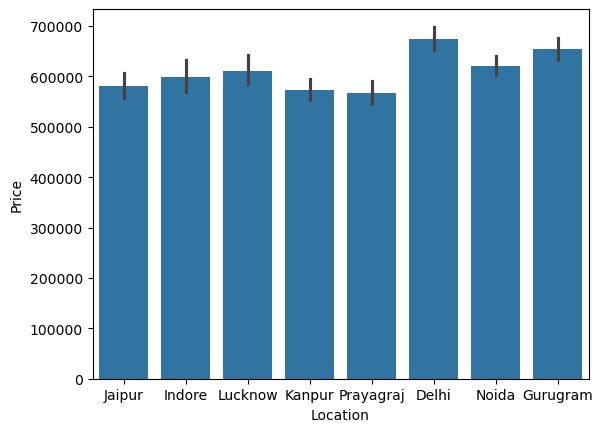

In [10]:
import seaborn as sns
sns.barplot(x=data['Location'],y=data['Price'])

In [11]:
data['location_hack']=data['Location'].map({
    'Delhi':4,
    'Gurugram':3,
    'Noida':2,
    'Lucknow':2,
    'Jaipur':1,
    'Indore':1,
    'Kanpur':1,
    'Prayagraj':1
    
})

C:\Users\Soni\AppData\Local\Temp\ipykernel_6784\17951922.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['location_hack']=data['Location'].map({


In [12]:
data

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price,Age,location_hack
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0,34,1
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0,20,1
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0,14,1
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0,33,2
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0,14,1
...,...,...,...,...,...,...,...,...,...,...,...
1118,1465.758301,5.0,1990,Lucknow,Gated Society,Semi-Furnished,Apartment,No,435487.0,36,2
1119,2461.048417,7.0,1988,Noida,Corner Plot,Unfurnished,Duplex,No,699925.0,38,2
1120,3558.174078,7.0,1989,Kanpur,Highway Facing,Unfurnished,Apartment,No,736329.0,37,1
1121,2179.880978,4.0,2011,Prayagraj,Residential Lane,Semi-Furnished,Duplex,No,533498.0,15,1


In [13]:
x=data.drop(['Price','Location','Age'],axis=1)
x=pd.get_dummies(x,columns=['Street_Type','Furnishing','Property_Type','Has_Pool'],drop_first=True)
y=data['Price']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.3,random_state=42)

model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

print(r2_score(y_test,y_pred))

0.9648856130347194


In [14]:
score=cross_val_score(
    model,
    x,y,
    scoring='r2',
    cv=5 
)
score.mean()

np.float64(0.9442723507830062)

<Axes: xlabel='Build_Year', ylabel='Price'>

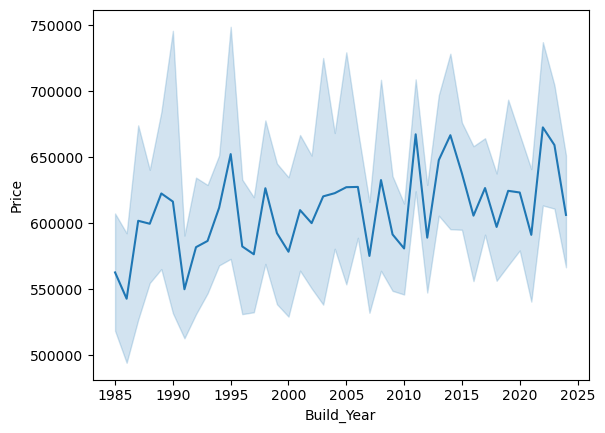

In [15]:
sns.lineplot(x=data['Build_Year'],y=data['Price'])

In [16]:
from sklearn.linear_model import Lasso
model=Lasso()

param={
    'alpha':[0.1,1,2,3,5,10]
}
from sklearn.model_selection import GridSearchCV
grid_model=GridSearchCV(
    model,
    param_grid=param,
    scoring='r2',
    cv=5
)
grid_model.fit(x_train,y_train)
grid_model.best_params_

{'alpha': 10}

In [17]:
y_pred=grid_model.predict(x_test)
r2_score(y_test,y_pred)

0.96489666886283